In [2]:
import os
import getpass
import pandas as pd
import geopandas as gpd
from sliderule import icesat2
import matplotlib.pyplot as plt

# 1. Prompt for Earthdata Credentials
print("Please enter your NASA Earthdata Login credentials.")
os.environ["EARTHDATA_USERNAME"] = input("Username: ")
os.environ["EARTHDATA_PASSWORD"] = getpass.getpass("Password: ")

# Also set standard earthaccess env variables just in case
os.environ["EARTHACCESS_USERNAME"] = os.environ["EARTHDATA_USERNAME"]
os.environ["EARTHACCESS_PASSWORD"] = os.environ["EARTHDATA_PASSWORD"]

# 2. Initialize SlideRule
icesat2.init("slideruleearth.io", verbose=False)

# 3. Define Polygon in dictionary format (Counter-Clockwise)
poly = [
    {"lon": -107.5, "lat": 39.0},
    {"lon": -107.0, "lat": 39.0},
    {"lon": -107.0, "lat": 39.5},
    {"lon": -107.5, "lat": 39.5},
    {"lon": -107.5, "lat": 39.0}
]

# 4. Configure Parameters for ATL06 + DEM Sampling
parms = {
    "poly": poly,
    "t0": "2021-01-01T00:00:00Z",
    "t1": "2021-01-31T23:59:59Z", 
    "len": 40.0,                      
    "res": 20.0, 
    "samples": {
        "dem": {"asset": "usgs3dep-1meter-dem"} 
    }
}

# 5. Process
print("\nRequesting ATL06 data and sampling USGS 3DEP DEM...")
gdf = icesat2.atl06p(parms)

# 6. Differencing and Plotting
if not gdf.empty:
    print(f"Successfully returned {len(gdf)} ATL06 points.")
    
    if 'dem.value' in gdf.columns:
        # Filter valid DEM points 
        valid_data = gdf[gdf['dem.value'] < 100000].copy() 
        
        if len(valid_data) > 0:
            # Calculate difference: h_mean (ICESat-2) - dem.value (USGS 3DEP)
            valid_data['dh'] = valid_data['h_mean'] - valid_data['dem.value']
            
            print(f"Processed {len(valid_data)} valid overlapping points for differencing.")
            
            plt.figure(figsize=(10, 6))
            plt.hist(valid_data['dh'], bins=100, range=(-20, 20), edgecolor='black')
            plt.title('Elevation Difference (ICESat-2 - USGS 3DEP DEM)')
            plt.xlabel('Elevation Difference (meters)')
            plt.ylabel('Count')
            plt.grid(True, alpha=0.3)
            plt.show()
        else:
            print("DEM sampling worked, but all values were NoData.")
    else:
        print("Error: 'dem.value' column missing. Trying changing 'usgs3dep' to 'usgs3dep-1meter'.")
else:
    print("No points returned. Ensure your Earthdata credentials are correct and the account has accepted the EULA for ICESat-2 data.")

Please enter your NASA Earthdata Login credentials.


Username:  meteodave
Password:  ········



Requesting ATL06 data and sampling USGS 3DEP DEM...


Alert <-2>: request <AppServer.20700> timed-out after 600 seconds waiting for endpoint proxy


Successfully returned 162211 ATL06 points.


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [15]:
from sliderule import icesat2

# 1. Initialize with VERBOSE=TRUE to catch server-side errors
icesat2.init("slideruleearth.io", verbose=True)

poly = [
    {"lon": -107.5, "lat": 39.0},
    {"lon": -107.0, "lat": 39.0},
    {"lon": -107.0, "lat": 39.5},
    {"lon": -107.5, "lat": 39.5},
    {"lon": -107.5, "lat": 39.0}
]

# Parameters strictly for ATL06 (NO DEM yet)
parms_base = {
    "poly": poly,
    "t0": "2021-01-01T00:00:00Z",
    "t1": "2021-12-31T23:59:59Z", 
    "len": 40.0,                      
    "res": 20.0
}

print("\n--- TEST 1: Requesting ONLY ICESat-2 ATL06 ---")
gdf_base = icesat2.atl06p(parms_base)
print(f"\nTest 1 Points Returned: {len(gdf_base)}")

if not gdf_base.empty:
    print("\n--- TEST 2: Adding USGS 3DEP DEM ---")
    parms_dem = parms_base.copy()
    parms_dem["samples"] = {"dem": {"asset": "usgs3dep"}}
    
    gdf_dem = icesat2.atl06p(parms_dem)
    print(f"\nTest 2 Points Returned: {len(gdf_dem)}")


--- TEST 1: Requesting ONLY ICESat-2 ATL06 ---

Test 1 Points Returned: 162211

--- TEST 2: Adding USGS 3DEP DEM ---

Test 2 Points Returned: 0


In [16]:
from sliderule import icesat2

icesat2.init("slideruleearth.io", verbose=False)

poly = [
    {"lon": -107.5, "lat": 39.0},
    {"lon": -107.0, "lat": 39.0},
    {"lon": -107.0, "lat": 39.5},
    {"lon": -107.5, "lat": 39.5},
    {"lon": -107.5, "lat": 39.0}
]

parms_base = {
    "poly": poly,
    "t0": "2021-01-01T00:00:00Z",
    "t1": "2021-12-31T23:59:59Z", 
    "len": 40.0,                      
    "res": 20.0
}

# List of common DEM assets available on SlideRule servers
test_assets = [
    "usgs3dep-1meter", 
    "usgs3dep", 
    "copernicus-dem",     # Global 30m DEM
    "cop-dem-glo-30",     # Alternate Copernicus name
    "srtm-v3",
    "srtm"
]

print("--- Testing Raster Assets ---")
for asset in test_assets:
    print(f"\nRequesting ATL06 + '{asset}'...")
    parms = parms_base.copy()
    parms["samples"] = {"dem": {"asset": asset}}
    
    # Try processing
    gdf = icesat2.atl06p(parms)
    print(f"Points Returned: {len(gdf)}")
    
    if not gdf.empty and 'dem.value' in gdf.columns:
        print(f"SUCCESS! The correct asset name is: {asset}")
        
        # Quick validation of the DEM data
        valid_dem = gdf[gdf['dem.value'] < 100000]
        print(f"Valid overlapping DEM points: {len(valid_dem)}")
        break

--- Testing Raster Assets ---

Requesting ATL06 + 'usgs3dep-1meter'...
Points Returned: 0

Requesting ATL06 + 'usgs3dep'...
Points Returned: 0

Requesting ATL06 + 'copernicus-dem'...
Points Returned: 0

Requesting ATL06 + 'cop-dem-glo-30'...
Points Returned: 0

Requesting ATL06 + 'srtm-v3'...
Points Returned: 0

Requesting ATL06 + 'srtm'...
Points Returned: 0


1. Requesting ICESat-2 ATL06 data from SlideRule...
   Returned 162211 ATL06 points.

2. Querying USGS 3DEP DEM using py3dep... (This may take a minute for 160k points)
   Successfully sampled 162211 points from USGS 3DEP.


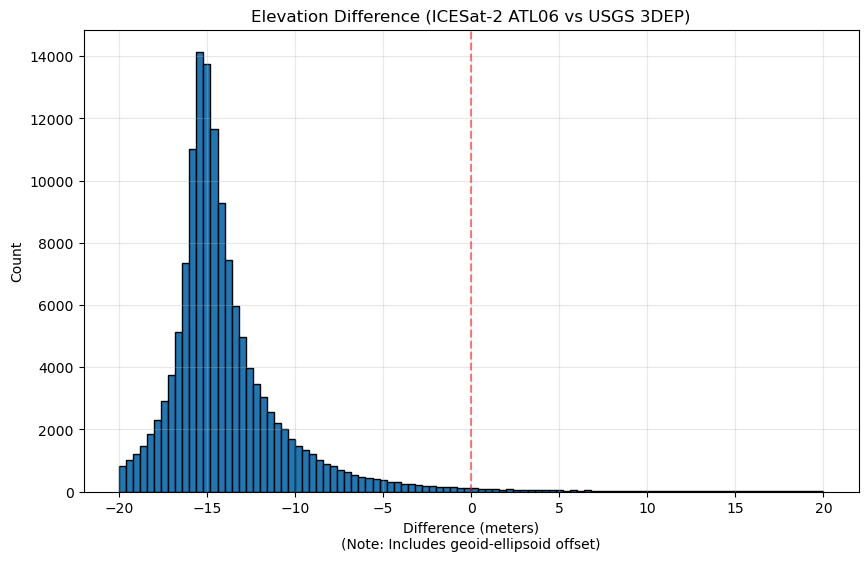

In [1]:
import pandas as pd
import geopandas as gpd
from sliderule import icesat2
import matplotlib.pyplot as plt
import py3dep

# 1. Initialize SlideRule 
icesat2.init("slideruleearth.io", verbose=False)

poly = [
    {"lon": -107.5, "lat": 39.0},
    {"lon": -107.0, "lat": 39.0},
    {"lon": -107.0, "lat": 39.5},
    {"lon": -107.5, "lat": 39.5},
    {"lon": -107.5, "lat": 39.0}
]

# 2. Process ATL06 (NO DEM sampling requested from the server)
parms = {
    "poly": poly,
    "t0": "2021-01-01T00:00:00Z",
    "t1": "2021-12-31T23:59:59Z", 
    "len": 40.0,                      
    "res": 20.0
}

print("1. Requesting ICESat-2 ATL06 data from SlideRule...")
gdf = icesat2.atl06p(parms)
print(f"   Returned {len(gdf)} ATL06 points.")

if not gdf.empty:
    print("\n2. Querying USGS 3DEP DEM using py3dep... (This may take a minute for 160k points)")
    
    # Extract the X (lon) and Y (lat) coordinates into a list of tuples
    coords = tuple(zip(gdf.geometry.x, gdf.geometry.y))
    
    # py3dep will hit the USGS servers and return the elevations for these exact points
    # SlideRule returns data in EPSG:4326 (WGS84 Lat/Lon)
    try:
        dem_elevations = py3dep.elevation_bycoords(coords, crs=gdf.crs)
        gdf['usgs_dem'] = dem_elevations
        
        # Filter out any points where the DEM returned NaN (e.g., outside US coverage)
        valid_data = gdf.dropna(subset=['usgs_dem']).copy()
        print(f"   Successfully sampled {len(valid_data)} points from USGS 3DEP.")
        
        # 3. Perform the Differencing
        # Note: ATL06 (h_mean) is WGS84 Ellipsoidal height. 
        # USGS 3DEP is typically NAVD88 Orthometric height. 
        # For rigorous science, you would apply a Geoid model offset here.
        valid_data['dh'] = valid_data['h_mean'] - valid_data['usgs_dem']
        
        # 4. Plotting
        plt.figure(figsize=(10, 6))
        plt.hist(valid_data['dh'], bins=100, range=(-20, 20), edgecolor='black')
        plt.title('Elevation Difference (ICESat-2 ATL06 vs USGS 3DEP)')
        plt.xlabel('Difference (meters)\n(Note: Includes geoid-ellipsoid offset)')
        plt.ylabel('Count')
        plt.grid(True, alpha=0.3)
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
        plt.show()

    except Exception as e:
        print(f"Error querying the USGS DEM: {e}")

In [8]:
import requests
import json
import pandas as pd
from sliderule import icesat2
import matplotlib.pyplot as plt

# 1. Initialize SlideRule
icesat2.init("slideruleearth.io", verbose=True)

poly = [
    [-107.5, 39.0],
    [-107.0, 39.0],
    [-107.0, 39.5],
    [-107.5, 39.5],
    [-107.5, 39.0]
]

# 2. Query Microsoft Planetary Computer STAC for USGS 3DEP Data
print("1. Querying Microsoft Planetary Computer for USGS 3DEP catalog...")
stac_url = "https://planetarycomputer.microsoft.com/api/stac/v1/search"
lons = [p[0] for p in poly]
lats = [p[1] for p in poly]
bbox = [min(lons), min(lats), max(lons), max(lats)]

stac_payload = {
    "collections": ["3dep-seamless"], # The seamless USGS 3DEP collection
    "bbox": bbox
}

response = requests.post(stac_url, json=stac_payload)
response.raise_for_status()
stac_items = response.json()

# 3. Build the SlideRule-compatible GeoJSON Catalog
features = []
for item in stac_items.get("features", []):
    # Extract the Cloud Optimized GeoTIFF URL from the STAC item
    cog_url = item["assets"]["data"]["href"]
    
    features.append({
        "type": "Feature",
        "geometry": item["geometry"],
        "properties": {"url": cog_url}
    })

geojson_catalog = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=poly) 

# 4. Configure ATL06 + DEM parameters injecting the PC catalog
parms = {
    "poly": poly,
    "t0": "2021-01-01T00:00:00Z",
    "t1": "2021-12-31T23:59:59Z", 
    "len": 40.0,                      
    "res": 20.0,
    "samples": {
        "dem": {
            "asset": "usgs3dep-1meter-dem", 
            "catalog": json.dumps(geojson_catalog) 
        }
    }
}

# 5. Process ATL06 and Sample
print("\n2. Requesting ATL06 data and sampling USGS 3DEP DEM on SlideRule...")
gdf = icesat2.atl06p(parms)


print(f"   Returned {len(gdf)} ATL06 points.")

# 6. Differencing and Plotting
if not gdf.empty and 'dem.value' in gdf.columns:
    valid_data = gdf[gdf['dem.value'] < 100000].copy() 
    
    if len(valid_data) > 0:
        valid_data['dh'] = valid_data['h_mean'] - valid_data['dem.value']
        
        print(f"\n3. Processed {len(valid_data)} valid overlapping points for differencing.")
        
        plt.figure(figsize=(10, 6))
        plt.hist(valid_data['dh'], bins=100, range=(-20, 20), edgecolor='black')
        plt.title('Elevation Difference (ICESat-2 - USGS 3DEP DEM)')
        plt.xlabel('Elevation Difference (meters)')
        plt.ylabel('Count')
        plt.grid(True, alpha=0.3)
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
        plt.show()
    else:
        print("DEM sampling worked, but all values were NoData.")
else:
    print("\nError: 'dem.value' column missing or no ATL06 points returned.")

1. Querying Microsoft Planetary Computer for USGS 3DEP catalog...


NameError: name 'earthdata' is not defined

In [7]:
import geopandas as gpd
from sliderule import icesat2, earthdata
import json

icesat2.init("slideruleearth.io", verbose=True)

poly = [
    {"lon": -107.25, "lat": 39.20},
    {"lon": -107.20, "lat": 39.20},
    {"lon": -107.20, "lat": 39.25},
    {"lon": -107.25, "lat": 39.25},
    {"lon": -107.25, "lat": 39.20}
]

# geojson_catalog = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=poly) 

parms = {
    "poly": poly,
    "t0": "2021-01-01T00:00:00Z",
    "t1": "2021-12-31T23:59:59Z",  
    # "samples": {
    #     "dem": {
    #             "asset": "usgs3dep-1meter-dem",
    #             "catalog": json.dumps(geojson_catalog) 
    #            } 
    # }
}

# 5. Process
print("\nRequesting ATL06 data and sampling USGS 3DEP DEM...")
gdf = icesat2.atl06(parms)
print(gdf)



Requesting ATL06 data and sampling USGS 3DEP DEM...


TypeError: atl06() missing 1 required positional argument: 'resource'

In [11]:
import pandas as pd
import geopandas as gpd
from sliderule import icesat2, earthdata
import matplotlib.pyplot as plt

icesat2.init("slideruleearth.io", verbose=False)

poly = [
    {"lon": -107.5, "lat": 39.0},
    {"lon": -90.0, "lat": 39.0},
    {"lon": -90.0, "lat": 45.0},
    {"lon": -107.5, "lat": 45.0},
    {"lon": -107.5, "lat": 39.0}
]

# 1. Query Earthdata for standard ATL06 granules intersecting our polygon
print("Querying Earthdata for ATL06 granules...")
granules = earthdata.cmr(
    short_name='ATL06',
    polygon=poly,
    time_start="2021-01-01T00:00:00Z",
    time_end="2021-12-31T23:59:59Z"
)
print(f"Found {len(granules)} ATL06 granules.")

parms = {
    "poly": poly,
    "samples": {
        "dem": {"asset": "copernicus-dem"} 
    }
}

# 2. Iterate through the granules, extract h_li, and sample the DEM
gdfs = []
for granule in granules:
    print(f"Processing {granule}...")
    # Read native ATL06 passing the resource (granule) directly
    df = icesat2.atl06(parms, resource=granule)
    print(df)
    if not df.empty:
        gdfs.append(df)

# 3. Differencing and Plotting
if gdfs:
    # Combine all individual granule dataframes into one
    gdf = pd.concat(gdfs)
    print(f"\nSuccessfully returned {len(gdf)} standard ATL06 points.")
    
    if 'dem.value' in gdf.columns:
        # Filter valid DEM points 
        valid_data = gdf[gdf['dem.value'] < 100000].copy() 
        
        if len(valid_data) > 0:
            # Calculate difference: h_li (ICESat-2 standard) - dem.value (Copernicus DEM)
            valid_data['dh'] = valid_data['h_li'] - valid_data['dem.value']
            
            print(f"Processed {len(valid_data)} valid overlapping points for differencing.")
            
            plt.figure(figsize=(10, 6))
            plt.hist(valid_data['dh'], bins=100, range=(-20, 20), edgecolor='black')
            plt.title('Elevation Difference (Standard ICESat-2 h_li - Copernicus DEM)')
            plt.xlabel('Elevation Difference (meters)')
            plt.ylabel('Count')
            plt.grid(True, alpha=0.3)
            plt.show()
        else:
            print("DEM sampling worked, but all values were NoData.")
    else:
        print("Error: 'dem.value' column missing.")
else:
    print("No points returned. The granules might not have valid data within this specific polygon.")

Querying Earthdata for ATL06 granules...


FatalError: error in request to https://sliderule.slideruleearth.io/source/earthdata: HTTP error <500> {'code': -5, 'error': 'number of CMR hits <531> exceeded maximum allowed <300> for ATL06'}

In [3]:
import pandas as pd
import geopandas as gpd
from sliderule import icesat2, earthdata
import matplotlib.pyplot as plt

icesat2.init("slideruleearth.io", verbose=False)

poly = [
    {"lon": -107.25, "lat": 45.20},
    {"lon": -107.20, "lat": 45.20},
    {"lon": -107.20, "lat": 45.25},
    {"lon": -107.25, "lat": 45.25},
    {"lon": -107.25, "lat": 45.20}
]

# 1. Query Earthdata for standard ATL06 granules intersecting our polygon
print("Querying Earthdata for ATL06 granules...")
granules = earthdata.cmr(
    short_name='ATL06',
    polygon=poly,
    time_start="2021-01-01T00:00:00Z",
    time_end="2021-12-31T23:59:59Z"
)
print(f"Found {len(granules)} ATL06 granules.")

parms = {
    "poly": poly,
    "samples": {
        "dem": {"asset": "copernicus-dem"} 
    }
}

# 2. Iterate through the granules, extract h_li, and sample the DEM
gdfs = []
for granule in granules:
    print(f"Processing {granule}...")
    # Read native ATL06 passing the resource (granule) directly
    df = icesat2.atl06(parms, resource=granule)
    
    if not df.empty:
        gdfs.append(df)

# 3. Differencing and Plotting
if gdfs:
    # Combine all individual granule dataframes into one
    gdf = pd.concat(gdfs)
    print(f"\nSuccessfully returned {len(gdf)} standard ATL06 points.")
    
    if 'dem.value' in gdf.columns:
        # Filter valid DEM points 
        valid_data = gdf[gdf['dem.value'] < 100000].copy() 
        
        if len(valid_data) > 0:
            # Calculate difference: h_li (ICESat-2 standard) - dem.value (Copernicus DEM)
            valid_data['dh'] = valid_data['h_li'] - valid_data['dem.value']
            
            print(f"Processed {len(valid_data)} valid overlapping points for differencing.")
            
            plt.figure(figsize=(10, 6))
            plt.hist(valid_data['dh'], bins=100, range=(-20, 20), edgecolor='black')
            plt.title('Elevation Difference (Standard ICESat-2 h_li - Copernicus DEM)')
            plt.xlabel('Elevation Difference (meters)')
            plt.ylabel('Count')
            plt.grid(True, alpha=0.3)
            plt.show()
        else:
            print("DEM sampling worked, but all values were NoData.")
    else:
        print("Error: 'dem.value' column missing.")
else:
    print("No points returned. The granules might not have valid data within this specific polygon.")

Querying Earthdata for ATL06 granules...
Found 4 ATL06 granules.
Processing ATL06_20211006065018_02111306_007_01.h5...
Processing ATL06_20211101171852_06151302_007_01.h5...
Processing ATL06_20210608123416_11561106_007_01.h5...
Processing ATL06_20210907081412_11561206_007_01.h5...
No points returned. The granules might not have valid data within this specific polygon.


In [4]:
import pandas as pd
import geopandas as gpd
from sliderule import icesat2, earthdata
import matplotlib.pyplot as plt

icesat2.init("slideruleearth.io", verbose=False)

# 0.2 x 0.2 degree box (large enough to guarantee tracks, small enough to help prevent USGS timeouts)
poly = [
    {"lon": -107.4, "lat": 39.1},
    {"lon": -107.2, "lat": 39.1},
    {"lon": -107.2, "lat": 39.3},
    {"lon": -107.4, "lat": 39.3},
    {"lon": -107.4, "lat": 39.1}
]

print("Querying Earthdata for ATL06 granules...")
granules = earthdata.cmr(
    short_name='ATL06',
    polygon=poly,
    time_start="2021-01-01T00:00:00Z",
    time_end="2021-12-31T23:59:59Z"
)
print(f"Found {len(granules)} ATL06 granules.")

parms = {
    "poly": poly,
    "samples": {
        "dem": {"asset": "usgs3dep-1meter-dem"} 
    }
}

gdfs = []
for granule in granules:
    print(f"Processing {granule}...")
    try:
        df = icesat2.atl06(parms, resource=granule)
        if not df.empty:
            gdfs.append(df)
            print(f"  -> Found {len(df)} points")
        else:
            print("  -> No points in this polygon for this granule")
    except Exception as e:
        print(f"  -> Failed to process {granule} (Likely USGS 3DEP timeout): {e}")

if gdfs:
    gdf = pd.concat(gdfs)
    print(f"\nSuccessfully returned {len(gdf)} standard ATL06 points.")
    
    if 'dem.value' in gdf.columns:
        valid_data = gdf[gdf['dem.value'] < 100000].copy() 
        
        if len(valid_data) > 0:
            valid_data['dh'] = valid_data['h_li'] - valid_data['dem.value']
            
            print(f"Processed {len(valid_data)} valid overlapping points for differencing.")
            
            plt.figure(figsize=(10, 6))
            plt.hist(valid_data['dh'], bins=100, range=(-20, 20), edgecolor='black')
            plt.title('Elevation Difference (Standard ICESat-2 h_li - USGS 3DEP DEM)')
            plt.xlabel('Elevation Difference (meters)')
            plt.ylabel('Count')
            plt.grid(True, alpha=0.3)
            plt.show()
        else:
            print("DEM sampling worked, but all values were NoData.")
    else:
        print("Error: 'dem.value' column missing.")
else:
    print("No points returned. Ensure Earthdata credentials are set and tracks intersect the polygon.")

Querying Earthdata for ATL06 granules...
Found 7 ATL06 granules.
Processing ATL06_20210903082229_10951206_007_01.h5...
  -> No points in this polygon for this granule
Processing ATL06_20210305170245_10951006_007_01.h5...
  -> No points in this polygon for this granule
Processing ATL06_20210206061053_06761002_007_01.h5...
  -> No points in this polygon for this granule
Processing ATL06_20210806213035_06761202_007_01.h5...
  -> No points in this polygon for this granule
Processing ATL06_20210508015043_06761102_007_01.h5...
  -> No points in this polygon for this granule
Processing ATL06_20211105171036_06761302_007_01.h5...
  -> No points in this polygon for this granule
Processing ATL06_20210604124235_10951106_007_01.h5...
  -> No points in this polygon for this granule
No points returned. Ensure Earthdata credentials are set and tracks intersect the polygon.
